In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
import sys
from tqdm import tqdm 

# set cosmology (for mdpl2)
from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck13')
a = 0.83760
redshift=1/a-1
H = cosmo.Hz(redshift)
h = cosmo.h

import halotools.sim_manager as sim_manager
import halotools.mock_observables as mock_observables

from compact.velocities.pw_moments import *
from compact.velocities.moments import *
from compact.streaming import *
from compact.tpcf import *
from compact.plot import *

from scipy.interpolate import UnivariateSpline

# reload project when changes are made
%load_ext autoreload
%autoreload 2

# plotting config
import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})
plt.rcParams['axes.labelsize'] = 20

import warnings
warnings.filterwarnings('ignore')

import psutil
psutil.Process().nice(10)

SyntaxError: expected ':' (streaming.py, line 90)

In [ ]:
# define halo quants

# path to MDPL2 halos, galaxies, data
halo_path = '/spiff/cosweeney/simulations/MDPL2/hlists/hlist_0.83760_update.hdf5'

# sim quantities
L_box = 1_000 # h^-1 Mpc
g_box = L_box // 4 # grid size

with h5.File(halo_path, 'r') as hdf:
    hm_cut = hdf['mvir'][()] >= 1e13 # halo mass, h^-1 M_sun

    hpos = np.array([
        hdf['x'][()][hm_cut],
        hdf['y'][()][hm_cut], 
        hdf['z'][()][hm_cut],
    ], dtype=np.float64).T 

    hpos = np.mod(hpos, L_box)

    hvel = np.array([
        hdf['vx'][()][hm_cut],
        hdf['vy'][()][hm_cut], 
        hdf['vz'][()][hm_cut],
    ], dtype=np.float64).T 

In [ ]:
# load real space cf

save_path = '/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/xi_hh_150_linbin.hdf5'

f = h5.File(save_path)

xi = f['xi'][()]

rbins = f['r_edges'][()]
rbins_c = f['r_cens'][()]


In [2]:
# load redshift space cf

save_path = '/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/RSCFs/s_mu_xi_hh.hdf5'

f = h5.File(save_path)

s_mu_xi = f['s_mu_xi'][()]

mu_bins = f['mu_edges'][()]
mu_bins_c = 0.5*(mu_bins[1:]+mu_bins[:-1])


In [3]:
from halotools.mock_observables import tpcf_multipole

monopole = tpcf_multipole(
    s_mu_xi, 
    mu_bins, 
    order=0
)
quadrupole = tpcf_multipole(
    s_mu_xi, 
    mu_bins, 
    order=2
)
hexadecapole = tpcf_multipole(
    s_mu_xi, 
    mu_bins, order=4)

ValueError: operands could not be broadcast together with shapes (71,) (70,) 

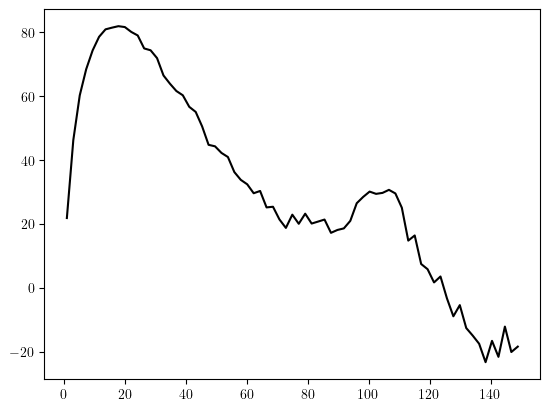

In [11]:
plt.plot(rbins_c, rbins_c**2*xi,
        label=r'$\xi^R(r)$', c='k')

plt.plot(rbins_c, rbins_c**2*monopole,
        label=r'$\xi^0(r)$')
plt.plot(rbins_c, rbins_c**2*quadrupole,
        label=r'$\xi^2(r)$')
plt.plot(rbins_c, rbins_c**2*hexadecapole,
        label=r'$\xi^4(r)$')
plt.legend()
plt.ylabel(r'$r^2\xi_{\rm hh}(r)$')
plt.xlabel(r'$r [\mathrm{Mpc}/h]$')

plt.xlim((0.5, 140))
plt.ylim((-120,120))
#plt.xscale('log')

plt.title(r'MDPL2 True Redshift-space $\xi_{\rm hh}(s, \mu)$')

In [16]:
# test out, benchmark moments function 
import time

frac = 0.1
idx = np.random.choice(len(hpos), int(frac * len(hpos)), replace=False)

t0 = time.perf_counter()
mom_dict = pairwise_velocity_moments_jackknife(hpos[idx], hvel[idx], rbins, L_box, 4)

t1 = time.perf_counter()

# Rough upper bound: scales as N^2
n_full, n_sub = len(hpos), len(idx)
print(f"Subsample took {t1-t0:.1f}s → full estimate: ~{(t1-t0) * (n_full/n_sub)**2:.0f}s, or {(t1-t0) * (n_full/n_sub)**2 / 3600:.3f} hr") 

Subsample took 6.4s → full estimate: ~642s, or 0.178 hr


In [ ]:
# compute pwv moments

mom_dict = pairwise_velocity_moments(hpos, hvel, rbins, L_box)

In [82]:
# save

save_path = '/spiffball/cosweeney/simulations/MDPL2/data/moments/'

with h5.File(save_path+"halo_moments.h5", "w") as f:
    for key, val in mom_dict.items():
        f.create_dataset(key, data=val)
        
    f.attrs["boxsize"] = L_box
    f.attrs["rbins"] = rbins

In [7]:
# load
save_path = '/spiffball/cosweeney/simulations/MDPL2/data/moments/'

mom_dict = {}
with h5.File(save_path+"halo_moments.h5", "r") as f:
    for key in f.keys():
        mom_dict[key] = f[key][:] # [:] loads the data into memory as a numpy array
        
    boxsize = f.attrs["boxsize"]
    rbins = f.attrs["rbins"]

In [18]:
# compute pwv moments, now with jk samples

full, jk_samples, cov = pairwise_velocity_moments_jackknife(hpos, hvel, rbins, L_box, 4)

# save

save_path = '/spiffball/cosweeney/simulations/MDPL2/data/moments/'

with h5.File(save_path + "halo_moments_jk_linbin.h5", "w") as f:

    # full-sample moments
    full_grp = f.create_group("full")
    for key, val in full.items():
        full_grp.create_dataset(key, data=val)

    # jk estimates
    jk_grp = f.create_group("jk_samples")
    for key, val in jk_samples.items():
        jk_grp.create_dataset(key, data=val)

    # covariance
    f.create_dataset("cov", data=cov)

    # metadata
    f.attrs["boxsize"] = L_box
    f.attrs["rbins"] = rbins
    f.attrs["n_jk_1d"] = 4
    f.attrs["n_jk"] = 4 ** 3

In [ ]:
# load jk moments 
save_path = '/spiffball/cosweeney/simulations/MDPL2/data/moments/'


with h5.File(save_path + "halo_moments_jk.h5", "r") as f:
    full       = {key: f["full"][key][:] for key in f["full"]}
    jk_samples = {key: f["jackknife"][key][:] for key in f["jackknife"]}
    cov        = f["covariance"][:]
    rbins      = f.attrs["rbins"]
    L_box      = f.attrs["boxsize"]
    n_jk_1d    = f.attrs["n_jk_1d"]

In [ ]:
# load moments computed with halotools: how do they compare?
save_path = '/spiffball/cosweeney/simulations/MDPL2/data/GSM_moments_hh_150.hdf5'

with h5.File(save_path, 'r') as f:
    v_12 = f['v_12'][()]
    s_12_r = f['s_12_r'][()]
    s_12_t = f['s_12_t'][()]

In [40]:
(1. + redshift)/100./cosmo.Ez(redshift) == h/(a*H)

np.True_

In [21]:
uc = h/a/H


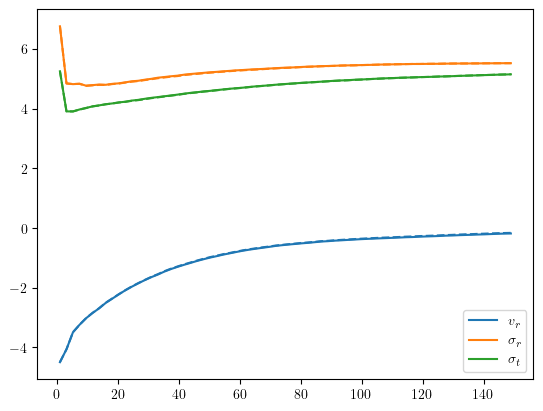

In [ ]:
# inspect

rbins_c = 0.5*(rbins[1:]+rbins[:-1])

plt.plot(rbins_c, uc*mom_dict['m10'],label=r'$v_r$') # In km/s
plt.plot(rbins_c, uc*mom_dict['c20'],label=r'$\sigma_r$')
plt.plot(rbins_c, uc*mom_dict['c02'],label=r'$\sigma_t$')

plt.plot(rbins_c, v_12, ls='--', c='C0') # In km/s (things agree exactly w/ halotools)
plt.plot(rbins_c, s_12_r, ls='--', c='C1')
plt.plot(rbins_c, s_12_t, ls='--', c='C2')

plt.legend()



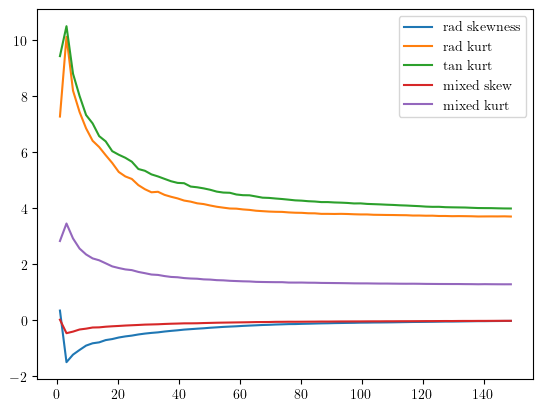

In [84]:
plt.plot(rbins_c, mom_dict['c30'],label=r'rad skewness') # Unitless, higher order moments. 
plt.plot(rbins_c, mom_dict['c40'],label=r'rad kurt')
plt.plot(rbins_c, mom_dict['c04'],label=r'tan kurt')
plt.plot(rbins_c, mom_dict['c12'],label=r'mixed skew')
plt.plot(rbins_c, mom_dict['c22'],label=r'mixed kurt')

plt.legend()

In [28]:
np.sqrt(cov[:, 0, 0]).shape

(70,)

In [33]:
full.keys()

dict_keys(['counts', 'm10', 'c20', 'c02', 'c30', 'c40', 'c04', 'c12', 'c22'])

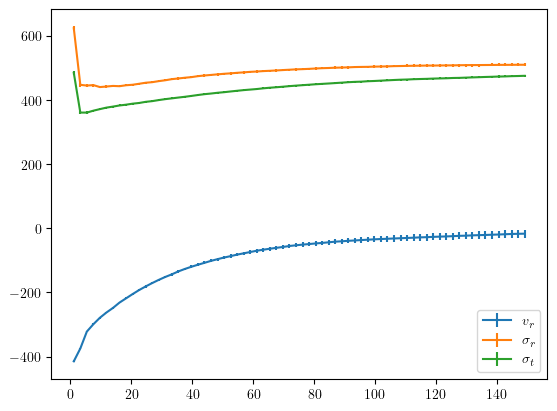

In [36]:
# inspect

rbins_c = 0.5*(rbins[1:]+rbins[:-1])

plt.errorbar(rbins_c, full['m10'], yerr=np.sqrt(cov[:, 0, 0]), label=r'$v_r$') # In km/s
plt.errorbar(rbins_c, full['c20'], yerr=np.sqrt(cov[:, 1, 1]), label=r'$\sigma_r$')
plt.errorbar(rbins_c, full['c02'], yerr=np.sqrt(cov[:, 2, 2]), label=r'$\sigma_t$')

plt.legend()



In [8]:
# does GSM look different with these?
from scipy.interpolate import UnivariateSpline

mubins_c = 0.5*(mu_bins[1:]+mu_bins[:-1])

uc = h/a/H

gaussian = moments2gaussian( 
    m_10=UnivariateSpline(rbins_c, uc*mom_dict['m10'], s=0, ext=3),  
    c_20=UnivariateSpline(rbins_c, (uc*mom_dict['c20'])**2, s=0, ext=3), #needs to be the _variance_, NOT dispersion!
    c_02=UnivariateSpline(rbins_c, (uc*mom_dict['c02'])**2, s=0, ext=3)
    # m_10=UnivariateSpline(rbins_c, v_12, s=0,ext=3),
    # c_20=UnivariateSpline(rbins_c, s_12_r, s=0,ext=3),
    # c_02=UnivariateSpline(rbins_c, s_12_t, s=0,ext=3)
)

gaussian_s_mu = simps_integrate(
    s_c=rbins_c, mu_c=mubins_c, 
    twopcf_function=UnivariateSpline(rbins_c,
                                     xi,s=0),
    los_pdf_function=gaussian,
    limit=160, 
    #epsilon=1e-16,
    n=300,
)

gaussian_monopole = tpcf_multipole(
    gaussian_s_mu,
    mu_bins, 
    order=0
)
gaussian_quadrupole = tpcf_multipole(
    gaussian_s_mu, 
    mu_bins, 
    order=2
)
gaussian_hexadecapole = tpcf_multipole(
    gaussian_s_mu, 
    mu_bins, 
    order=4
)

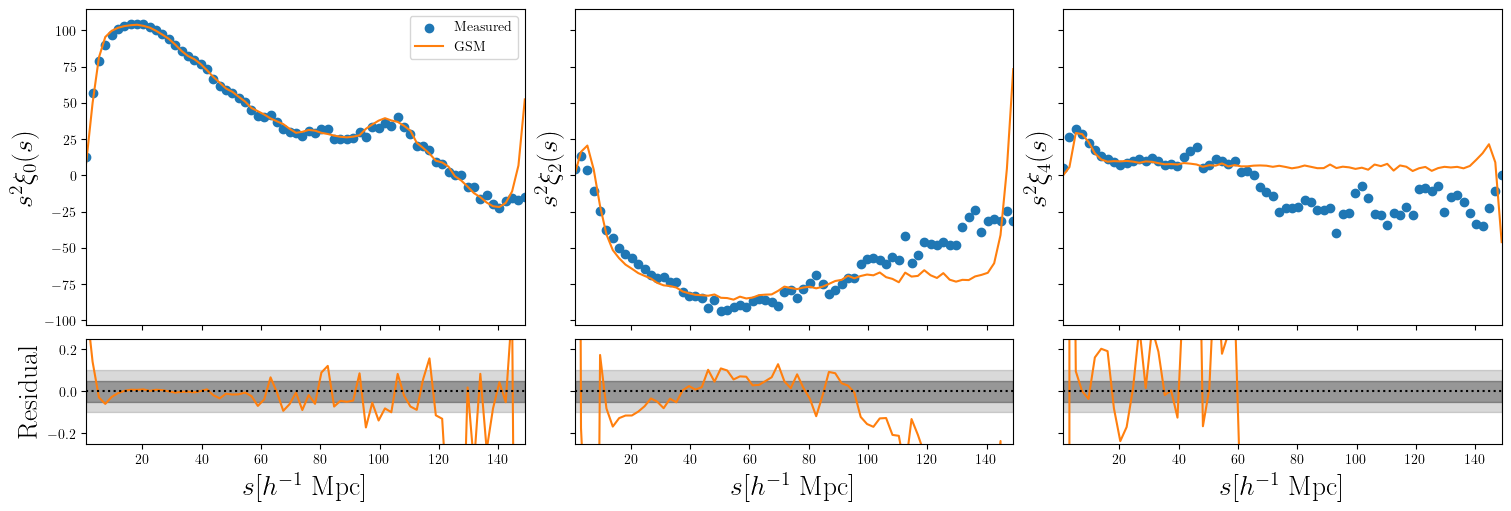

In [83]:
fig, axes = plot_multipoles_n_residuals(rbins_c, [monopole, quadrupole, hexadecapole], errs=None, preds=[gaussian_monopole, gaussian_quadrupole, gaussian_hexadecapole], label='GSM')

In [87]:
# do centrals gives different results?

halo_path = '/spiff/cosweeney/simulations/MDPL2/hlists/hlist_0.83760_update.hdf5'

# sim quantities
L_box = 1_000 # h^-1 Mpc
g_box = L_box // 4 # grid size

with h5.File(halo_path, 'r') as hdf:
    hm_cut = (hdf['mvir'][()] >= 1e13) & (hdf['upid'][()] == -1) # centrals only

    hpos = np.array([
        hdf['x'][()][hm_cut],
        hdf['y'][()][hm_cut], 
        hdf['z'][()][hm_cut],
    ], dtype=np.float64).T 

    hpos = np.mod(hpos, L_box)

    hvel = np.array([
        hdf['vx'][()][hm_cut],
        hdf['vy'][()][hm_cut], 
        hdf['vz'][()][hm_cut],
    ], dtype=np.float64).T 

In [88]:
# compute real-space \xi_hh

save_path = '/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/'

rbins = np.linspace(0.01, 150, 70+1) # make sure this is the same _everywhere_
rbins_c = 0.5*(rbins[1:] + rbins[:-1])

xi = mock_observables.tpcf(hpos, rbins, period=L_box, num_threads=84)

with h5.File(save_path+'xihh_centrals.hdf5', 'w') as f:
    f.create_dataset(name=f'xi', data=xi, dtype=np.float64)
    f.create_dataset(name=f'r_cens', data=rbins_c, dtype=np.float64)
    f.create_dataset(name=f'r_edges', data=rbins, dtype=np.float64)

In [89]:
# compute RS cg correlation function
from astropy.cosmology import Planck13

save_path = '/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/RSCFs/'

#s, mu bins
mu_bins = np.linspace(0,1,120)
rbins = np.linspace(0.01, 150, 70+1) # make sure this is the same _everywhere_
rbins_c = 0.5*(rbins[1:] + rbins[:-1])

s_mu_xi = compute_tpcf_s_mu(
    s=rbins, 
    mu=mu_bins, 
    pos=hpos, 
    vel=hvel, 
    los_direction=2, 
    redshift=redshift,
    cosmology=Planck13, 
    boxsize=L_box,
    num_threads=84, 
)

with h5.File(save_path+'s_mu_xi_hh_centrals.hdf5', 'w') as f:
    f.create_dataset(name=f's_mu_xi', data=s_mu_xi, dtype=np.float64)
    f.create_dataset(name=f'r_cens', data=rbins_c, dtype=np.float64)
    f.create_dataset(name=f'r_edges', data=rbins, dtype=np.float64)
    f.create_dataset(name=f'mu_edges', data=mu_bins, dtype=np.float64)

In [90]:
from halotools.mock_observables import tpcf_multipole

monopole = tpcf_multipole(
    s_mu_xi, 
    mu_bins, 
    order=0
)
quadrupole = tpcf_multipole(
    s_mu_xi, 
    mu_bins, 
    order=2
)
hexadecapole = tpcf_multipole(
    s_mu_xi, 
    mu_bins, order=4)

Text(0.5, 1.0, 'MDPL2 True Redshift-space $\\xi^c_{\\rm hh}(s, \\mu)$')

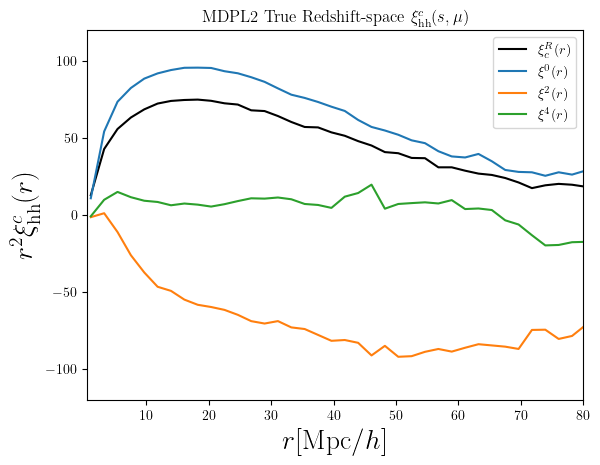

In [91]:
plt.plot(rbins_c, rbins_c**2*xi,
        label=r'$\xi^R_c(r)$', c='k')

plt.plot(rbins_c, rbins_c**2*monopole,
        label=r'$\xi^0(r)$')
plt.plot(rbins_c, rbins_c**2*quadrupole,
        label=r'$\xi^2(r)$')
plt.plot(rbins_c, rbins_c**2*hexadecapole,
        label=r'$\xi^4(r)$')
plt.legend()
plt.ylabel(r'$r^2\xi_{\rm hh}^c(r)$')
plt.xlabel(r'$r [\mathrm{Mpc}/h]$')

plt.xlim((0.5, 80))
plt.ylim((-120,120))
#plt.xscale('log')

plt.title(r'MDPL2 True Redshift-space $\xi^c_{\rm hh}(s, \mu)$')

In [92]:
# compute pwv moments

mom_dict = pairwise_velocity_moments(hpos, hvel, rbins, L_box)

In [93]:
# save

save_path = '/spiffball/cosweeney/simulations/MDPL2/data/moments/'

with h5.File(save_path+"central_halo_moments.h5", "w") as f:
    for key, val in mom_dict.items():
        f.create_dataset(key, data=val)
        
    f.attrs["boxsize"] = L_box
    f.attrs["rbins"] = rbins

In [ ]:
# does GSM look different with these?

mubins_c = 0.5*(mu_bins[1:]+mu_bins[:-1])

uc = h/a/H

gaussian = moments2gaussian( 
    m_10=UnivariateSpline(rbins_c, uc*mom_dict['m10'], s=0, ext=3),  
    c_20=UnivariateSpline(rbins_c, uc*mom_dict['c20'], s=0, ext=3),
    c_02=UnivariateSpline(rbins_c, uc*mom_dict['c02'], s=0, ext=3)
)

gaussian_s_mu = simps_integrate(
    s_c=rbins_c, mu_c=mubins_c, 
    twopcf_function=UnivariateSpline(rbins_c,
                                     xi,s=0),
    los_pdf_function=gaussian,
    limit=160, 
    #epsilon=1e-16,
    n=300,
)

gaussian_monopole = tpcf_multipole(
    gaussian_s_mu,
    mu_bins, 
    order=0
)
gaussian_quadrupole = tpcf_multipole(
    gaussian_s_mu, 
    mu_bins, 
    order=2
)
gaussian_hexadecapole = tpcf_multipole(
    gaussian_s_mu, 
    mu_bins, 
    order=4
)

Text(0.5, 0.98, '$\\it{Central}$ halos')

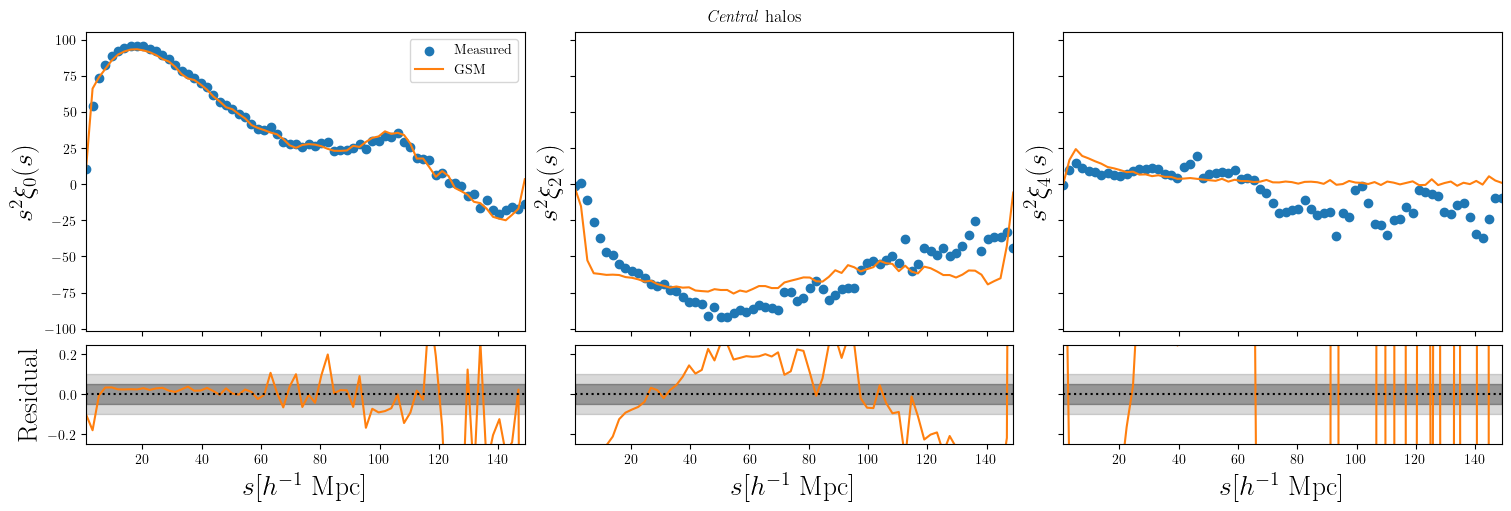

In [101]:
fig, axes = plot_multipoles_n_residuals(rbins_c, [monopole, quadrupole, hexadecapole], errs=None, preds=[gaussian_monopole, gaussian_quadrupole, gaussian_hexadecapole], label='GSM')

fig.suptitle(r'$\it{Central}$ halos')

In [ ]:
# inconclusive...

In [9]:
# what about the skew-t?

from compact.velocities.moments import *

In [11]:
moments = np.array([mom_dict[key] for key in mom_dict.keys()]).T
# columns: 0=c02, 1=c04, 2=c12, 3=c20, 4=c22, 5=c30, 6=c40, 7=counts, 8=m10

sig_t = moments[:, 0].copy()   # c02 = sigma_t
sig_r = moments[:, 3].copy()   # c20 = sigma_r

moments[:, 0] = sig_t**2                        # c02: sigma_t -> variance
moments[:, 1] = moments[:, 1] * sig_t**4        # c04: unstandardize
moments[:, 2] = moments[:, 2] * sig_r**2 * sig_t  # c12: unstandardize

moments[:, 3] = sig_r**2                        # c20: sigma_r -> variance
moments[:, 4] = moments[:, 4] * sig_r**2 * sig_t**2  # c22: unstandardize
moments[:, 5] = moments[:, 5] * sig_r**3        # c30: unstandardize
moments[:, 6] = moments[:, 6] * sig_r**4        # c40: unstandardize

moments = np.delete(moments, -2, axis=1)  # remove counts

#moments[:, :3] *= uc # convert moments to Mpc/h
moments.shape

(70, 8)

In [42]:
mom_dict.keys()

dict_keys(['c02', 'c04', 'c12', 'c20', 'c22', 'c30', 'c40', 'counts', 'm10'])

In [12]:
uc = h/a/H

skewt = moments2skewt( 
    m_10=UnivariateSpline(rbins_c, uc*mom_dict['m10'], s=0, ext=3, k=5),  
    c_20=UnivariateSpline(rbins_c, (uc*mom_dict['c20'])**2, s=0, ext=3, k=5),
    c_02=UnivariateSpline(rbins_c, (uc*mom_dict['c02'])**2, s=0, ext=3, k=5), 
    c_12=UnivariateSpline(rbins_c, mom_dict['c12']* sig_r**2 * sig_t, s=0, ext=3, k=5), 
    c_30=UnivariateSpline(rbins_c, mom_dict['c30']* sig_r**3, s=0, ext=3, k=5),
    c_40=UnivariateSpline(rbins_c, mom_dict['c40']* sig_r**4, s=0, ext=3, k=5),
    c_04=UnivariateSpline(rbins_c, mom_dict['c04']* sig_t**4, s=0, ext=3, k=5),
    c_22=UnivariateSpline(rbins_c, mom_dict['c22']* sig_r**2 * sig_t**2, s=0, ext=3, k=5), 

    r_max=200, 
    n_eval=200
)


In [13]:
skewt_s_mu = simps_integrate(
    s_c=rbins_c, mu_c=mu_bins_c, 
    twopcf_function=UnivariateSpline(rbins_c,
                                     xi,s=0),
    los_pdf_function=skewt,
    limit=160, 
    epsilon=0.01,
    #n=300,
)

skewt_monopole = tpcf_multipole(
    skewt_s_mu,
    mu_bins, 
    order=0
)
skewt_quadrupole = tpcf_multipole(
    skewt_s_mu, 
    mu_bins, 
    order=2
)
skewt_hexadecapole = tpcf_multipole(
    skewt_s_mu, 
    mu_bins, 
    order=4)

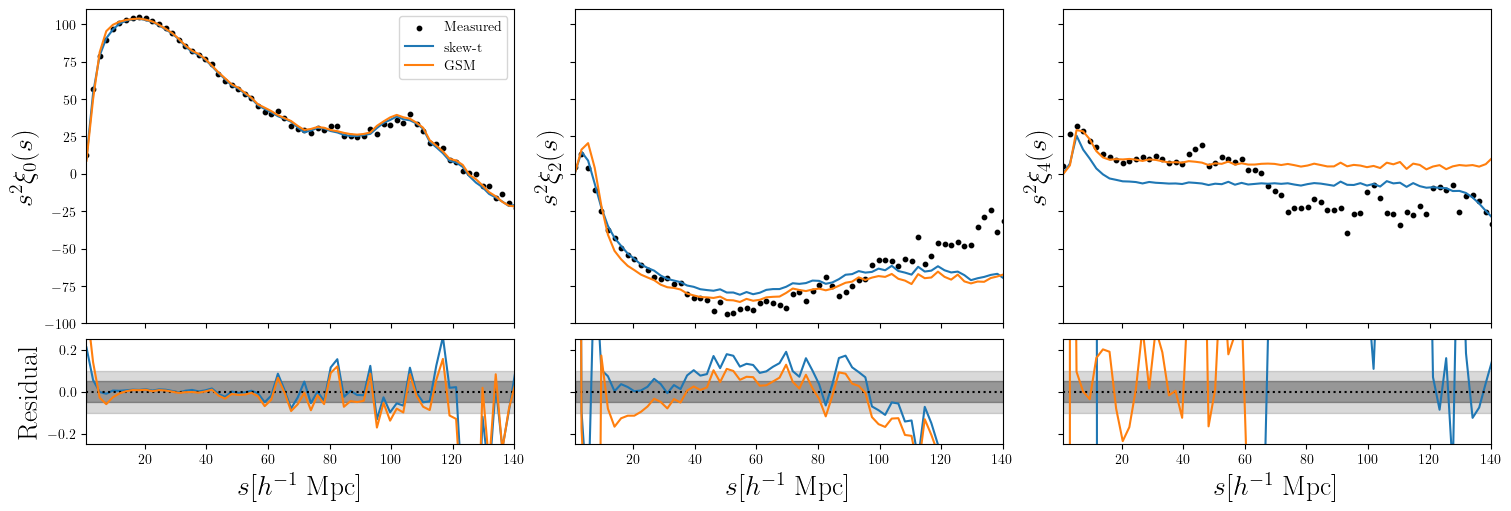

In [ ]:
# fig, axes = plot_multipoles_n_residuals(rbins_c, [monopole, quadrupole, hexadecapole], errs=None, preds=[gaussian_monopole, gaussian_quadrupole, gaussian_hexadecapole], label='GSM')

fig, axes = plot_multipoles_n_residuals(rbins_c, [monopole, quadrupole, hexadecapole], errs=None, preds=[skewt_monopole, skewt_quadrupole, skewt_hexadecapole], label='skew-t',)

gaussian_multipoles = [gaussian_monopole, gaussian_quadrupole, gaussian_hexadecapole]
multipoles = [monopole, quadrupole, hexadecapole]

for i, gm in enumerate(gaussian_multipoles):
    axes[0, i].plot(rbins_c, rbins_c**2*gm, label='GSM')

    axes[1, i].plot(rbins_c, (multipoles[i]-gm)/gm)

axes[0, 0].set_ylim((-100, 110))
axes[0, 0].set_xlim((1, 140))
axes[0, 1].set_xlim((1, 140))
axes[0, 2].set_xlim((1, 140))

axes[0, 0].legend()

In [15]:
# load JK estimates from pycorr

save_path = '/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/RSCFs/xi_smu_hh_pycorr.hdf5'


with h5.File(save_path, 'r') as f:
    xi_ell = f['xi_ell'][()]
    xi_ell_cov = f['xi_ell_cov'][()]

nells = 3
xi_ell_std = np.array(np.array_split(np.diag(xi_ell_cov)**0.5, nells))

In [16]:
xi_ell_cov.shape

(210, 210)

In [17]:
3*len(rbins_c)

210

In [110]:
xi_ell.shape

(3, 70)

In [117]:
xi_ell_std.shape

(3, 70)

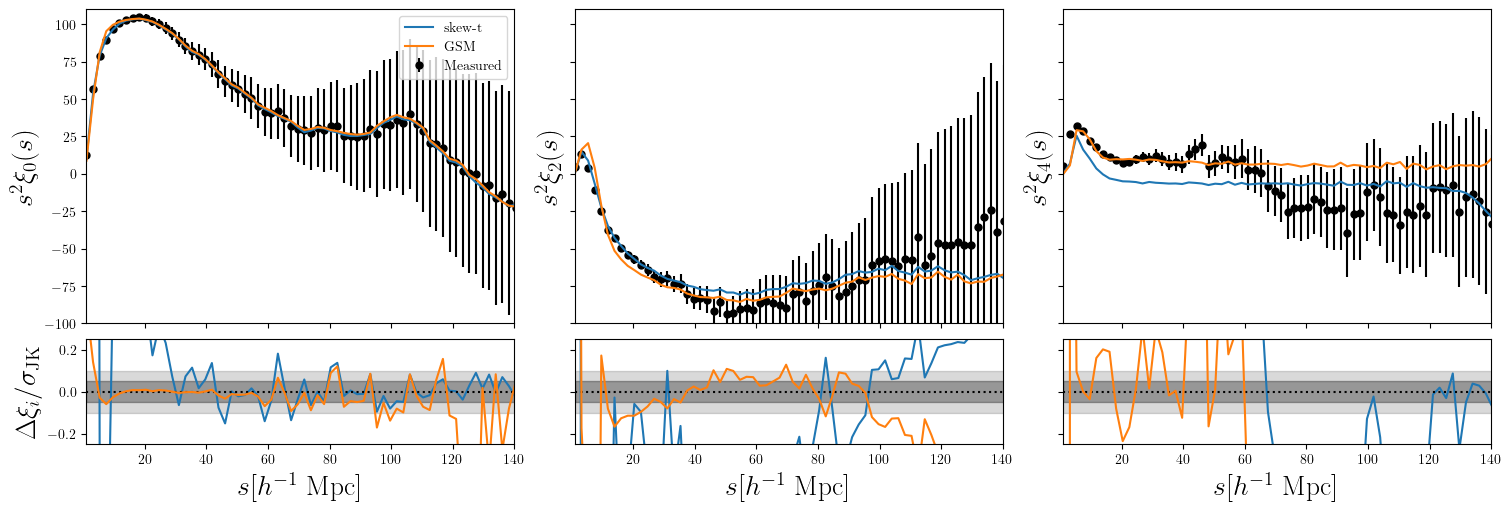

In [122]:
# plot with covariances

fig, axes = plot_multipoles_n_residuals(rbins_c, xi_ell, errs=xi_ell_std, preds=[skewt_monopole, skewt_quadrupole, skewt_hexadecapole], label='skew-t',)

gaussian_multipoles = [gaussian_monopole, gaussian_quadrupole, gaussian_hexadecapole]
multipoles = [monopole, quadrupole, hexadecapole]

for i, gm in enumerate(gaussian_multipoles):
    axes[0, i].plot(rbins_c, rbins_c**2*gm, label='GSM')

    axes[1, i].plot(rbins_c, (multipoles[i]-gm)/gm)


axes[0, 0].set_ylim((-100, 110))
axes[0, 0].set_xlim((1, 140))
axes[0, 1].set_xlim((1, 140))
axes[0, 2].set_xlim((1, 140))

axes[0, 0].legend()

In [ ]:
mom_list = list(mom_dict.keys())

mom_list.remove('counts')
mom_list

['c02', 'c04', 'c12', 'c20', 'c22', 'c30', 'c40', 'm10']

In [38]:
mom_dict.keys()

dict_keys(['c02', 'c04', 'c12', 'c20', 'c22', 'c30', 'c40', 'counts', 'm10'])

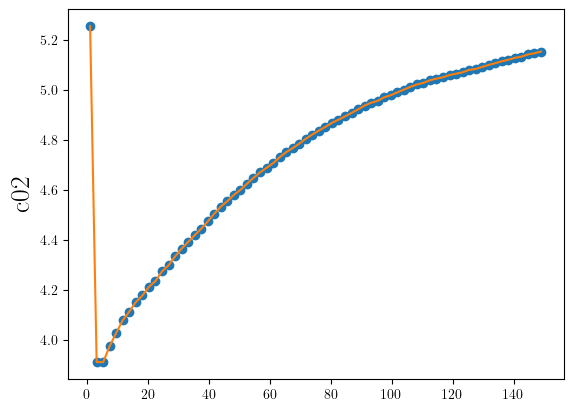

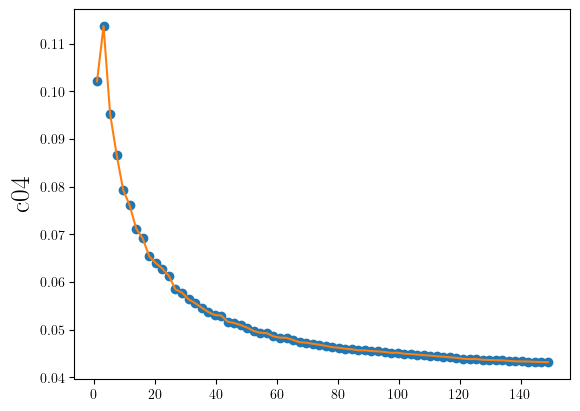

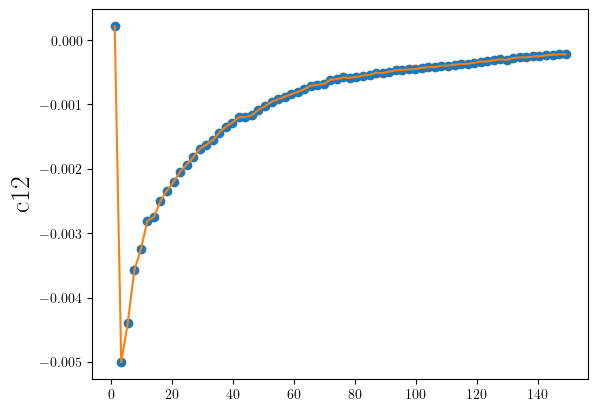

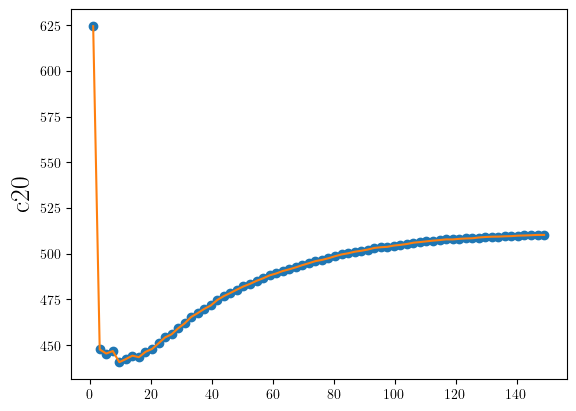

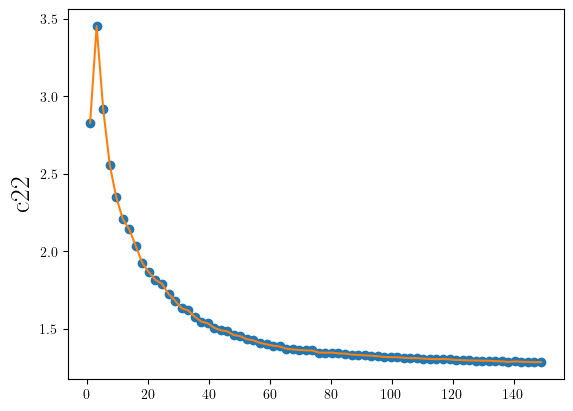

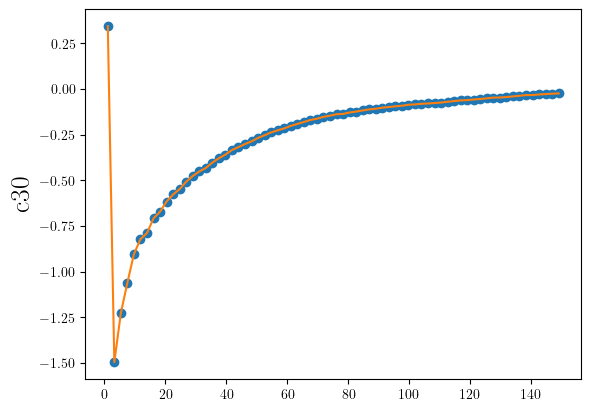

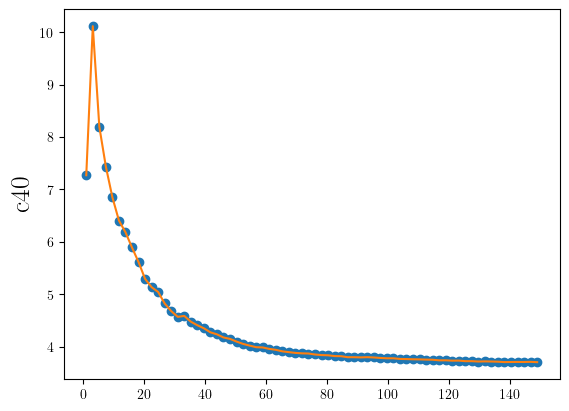

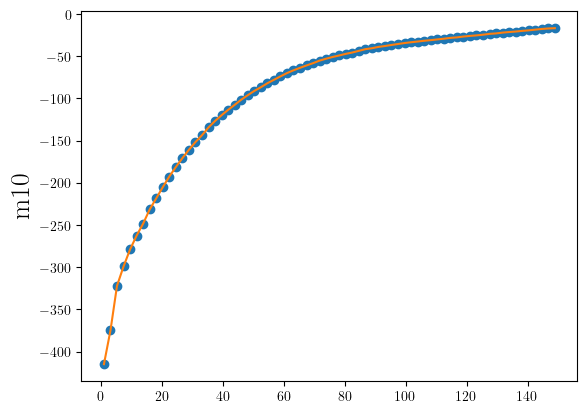

In [77]:
for mom in range(moments.shape[-1]):
    plt.scatter(rbins_c, moments[:, mom])
    plt.plot(rbins_c, UnivariateSpline(rbins_c, moments[:, mom], s=0, ext=3, k=5)(rbins_c), c='C1')
    plt.ylabel(mom_list[mom])
    plt.show()

In [45]:
# now with the compact model
from scipy.interpolate import interp1d

def sigma_mod(x, sigma0, A_rho, sigma_rho):
    return np.sqrt(2 * sigma0**2 * (1 - A_rho * np.exp(-x / sigma_rho)))

def delta_mod(x, A_delta, sigma_delta):
    return A_delta * x / (sigma_delta + x)

class SkewTMeanInterpolator:
    """
    Pre-computes the relationship between (Delta_mean / sigma_v) and (omega, alpha)
    for a Skew-T distribution using the algebraic mean. 
    """
    def __init__(self, nu=6, alpha_bounds=(-15, 15), pts=1000):
        self.nu = nu
        
        # We can increase 'pts' since this is now an instantaneous vectorized calculation
        alphas = np.linspace(alpha_bounds[0], alpha_bounds[1], pts)
        
        # 1. Delta coefficient for Azzalini Skew-T
        delta = alphas / np.sqrt(1 + alphas**2)
        
        # 2. Exact Mean of standard Skew-T (xi=0, omega=1)
        # mu_z = delta * sqrt(nu / pi) * [Gamma((nu - 1) / 2) / Gamma(nu / 2)]
        gamma_factor = gamma((nu - 1) / 2) / gamma(nu / 2)
        mu_z = delta * np.sqrt(nu / np.pi) * gamma_factor
        
        # 3. Exact Standard Deviation of standard Skew-T
        var_z = (nu / (nu - 2)) - mu_z**2
        sig_z = np.sqrt(var_z)
        
        # 4. Ratio R = Delta_mean / sigma_v for standard distribution
        # Assuming Delta_mean = xi - mean = 0 - mu_z = -mu_z
        R_vals = -mu_z / sig_z
        
        # interp1d requires the x-array (R_vals) to be strictly monotonically increasing.
        # As alpha increases, R_vals strictly decreases, so we must reverse the arrays.
        if R_vals[-1] < R_vals[0]:
            valid_R = R_vals[::-1]
            valid_alphas = alphas[::-1]
        else:
            valid_R = R_vals
            valid_alphas = alphas
            
        # Interpolator 1: Ratio -> alpha (Upgraded to cubic for smooth analytical data)
        self.R_to_alpha = interp1d(valid_R, valid_alphas, kind='cubic', 
                                   bounds_error=False, 
                                   fill_value=(valid_alphas[0], valid_alphas[-1]))
        
        # Interpolator 2: alpha -> standard deviation
        self.alpha_to_sigZ = interp1d(alphas, sig_z, kind='cubic', 
                                      bounds_error=False, 
                                      fill_value=(sig_z[0], sig_z[-1]))

    def get_skew_params(self, delta_mean, sig_v):
        """Maps physical parameters (Delta_mean, sigma_v) to Skew-T parameters (omega, alpha)"""
        ratio = delta_mean / sig_v
        alpha = self.R_to_alpha(ratio)
        sig_z = self.alpha_to_sigZ(alpha)
        omega = sig_v / sig_z
        return omega, alpha
    
# Instantiate this globally so it isn't rebuilt on every function call
skew_interp = SkewTMeanInterpolator(nu=6)

sig_pars = np.array([0.20281935253098268, 27.382880273166126])
del_pars = np.array([47.766923483904314, 0.29581892896320244])

def Pv_compact(v, r_p, r_los, mean_vr, pars=[*sig_pars, *del_pars]):
    """
    Evaluates P(v | r_p, r_los, M) modeled as a Skew-T distribution using the compact model.
    """
    # 1. Coordinate transformations
    r = np.sqrt(r_p**2 + r_los**2)
    x = r - r_p
    
    # 2. Evaluate physical quantities via your models
    mu = mean_vr(r) * r_los/r  #vlos_mean_vec(r_p, r_los, M)
    sig_v = sigma_mod(x, 355, *pars[:2])
    
    # Enforce symmetry: Delta flips sign when rlos is negative
    sign_rlos = np.where(r_los != 0, np.sign(r_los), 1.0)
    delta_val = delta_mod(x, *pars[2:]) * sign_rlos
    
    # 3. Interpolate standard Skew-T parameters
    omega, alpha = skew_interp.get_skew_params(delta_val, sig_v)
    
    # 4. Location parameter is purely algebraic
    xi = mu + delta_val
    
    # 5. Evaluate Skew-T PDF
    nu = skew_interp.nu
    z = (v - xi) / omega
    
    # Azzalini's Skew-T formulation: 2 * t.pdf(z) * t.cdf(alpha * z * sqrt...)
    arg = alpha * z * np.sqrt((nu + 1) / (nu + z**2))
    pdf = (2 / omega) * t.pdf(z, nu) * t.cdf(arg, nu + 1)
    
    return pdf

mean_vr_interp = UnivariateSpline(rbins_c, mom_dict['m10'][()], s=0, k=5, ext=3)

Text(0.5, 0, '$v_\\parallel [Mpc/h]$')

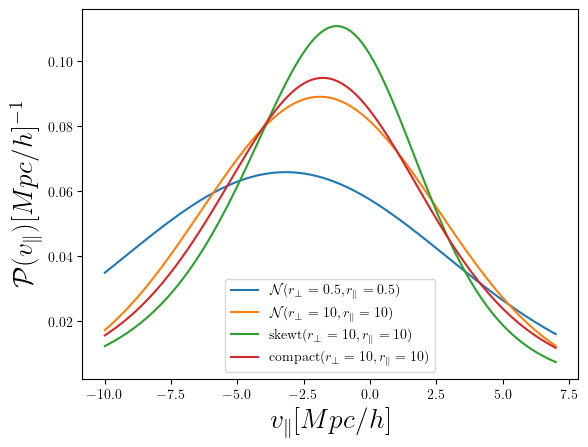

In [46]:
vlos = np.linspace(-10.,7.,100)
plt.plot(vlos, gaussian(vlos,r_perp=0.5,r_parallel=0.5)[0],
        label=r'$\mathcal{N}(r_\perp = 0.5, r_\parallel = 0.5)$')
plt.plot(vlos, gaussian(vlos,r_perp=10.,r_parallel=10.)[0],
        label=r'$\mathcal{N}(r_\perp = 10, r_\parallel = 10)$')

r_pt = np.array([10.])
r_lt = np.array([10.])

rpt, rlt = np.meshgrid(r_pt, r_lt, indexing='ij')
plt.plot(vlos, skewt(vlos,r_perp=rpt,r_parallel=rlt).squeeze(),
        label=r'skewt$(r_\perp = 10, r_\parallel = 10)$')
plt.plot(vlos, (1/uc)*Pv_compact((1/uc)*vlos, 10., 10., mean_vr_interp), label=r'compact$(r_\perp = 10, r_\parallel = 10)$')
plt.legend()
plt.ylabel(r'$\mathcal{P}(v_\parallel) [Mpc/h]^{-1}$')
plt.xlabel(r'$v_\parallel [Mpc/h]$')



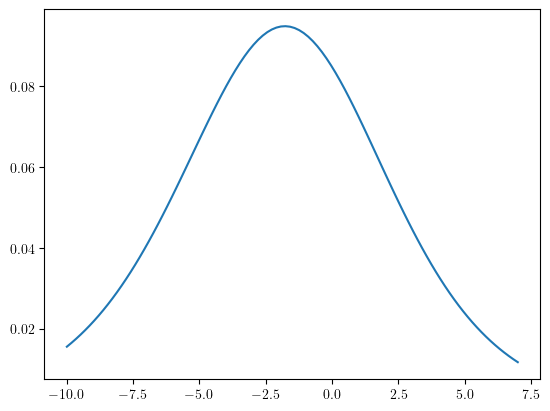

In [43]:
plt.plot(vlos, compact(vlos, 10, 10))

In [47]:
compact = lambda v, rp, rl: (1/uc)*Pv_compact(v/uc, rp, rl, mean_vr_interp)

compact_s_mu = simps_integrate(
    s_c=rbins_c, mu_c=mu_bins_c, 
    twopcf_function=UnivariateSpline(rbins_c,
                                     xi,s=0),
    los_pdf_function=compact,
    limit=160, 
    epsilon=0.01,
    #n=300,
)

compact_monopole = tpcf_multipole(
    compact_s_mu,
    mu_bins, 
    order=0
)
compact_quadrupole = tpcf_multipole(
    compact_s_mu, 
    mu_bins, 
    order=2
)
compact_hexadecapole = tpcf_multipole(
    compact_s_mu, 
    mu_bins, 
    order=4)

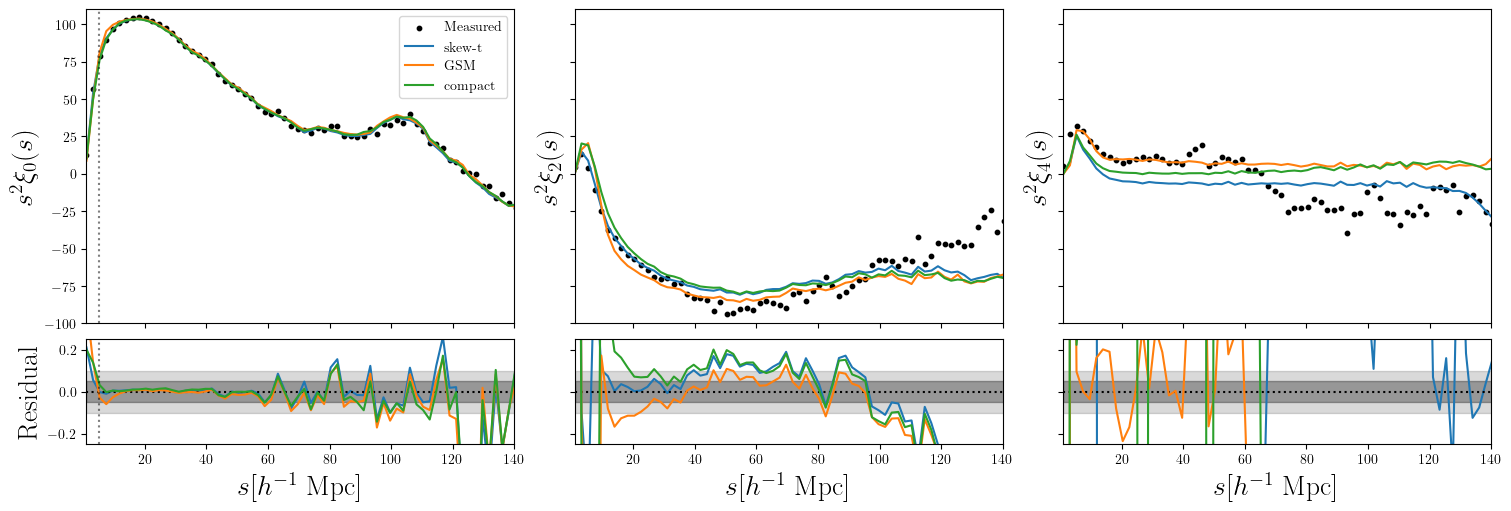

In [55]:
fig, axes = plot_multipoles_n_residuals(rbins_c, [monopole, quadrupole, hexadecapole], errs=None, preds=[skewt_monopole, skewt_quadrupole, skewt_hexadecapole], label='skew-t',)

compact_multipoles = [compact_monopole, compact_quadrupole, compact_hexadecapole]
gaussian_multipoles = [gaussian_monopole, gaussian_quadrupole, gaussian_hexadecapole]
multipoles = [monopole, quadrupole, hexadecapole]

for i, gm in enumerate(gaussian_multipoles):
    axes[0, i].plot(rbins_c, rbins_c**2*gm, label='GSM')

    axes[1, i].plot(rbins_c, (multipoles[i]-gm)/gm)

    axes[0, i].plot(rbins_c, rbins_c**2*compact_multipoles[i], label='compact')

    axes[1, i].plot(rbins_c, (multipoles[i]-compact_multipoles[i])/compact_multipoles[i])


axes[0, 0].axvline(5, c='k', ls=':', alpha=0.5)
axes[1, 0].axvline(5, c='k', ls=':', alpha=0.5)

axes[0, 0].set_ylim((-100, 110))
axes[0, 0].set_xlim((1, 140))
axes[0, 1].set_xlim((1, 140))
axes[0, 2].set_xlim((1, 140))

axes[0, 0].legend()

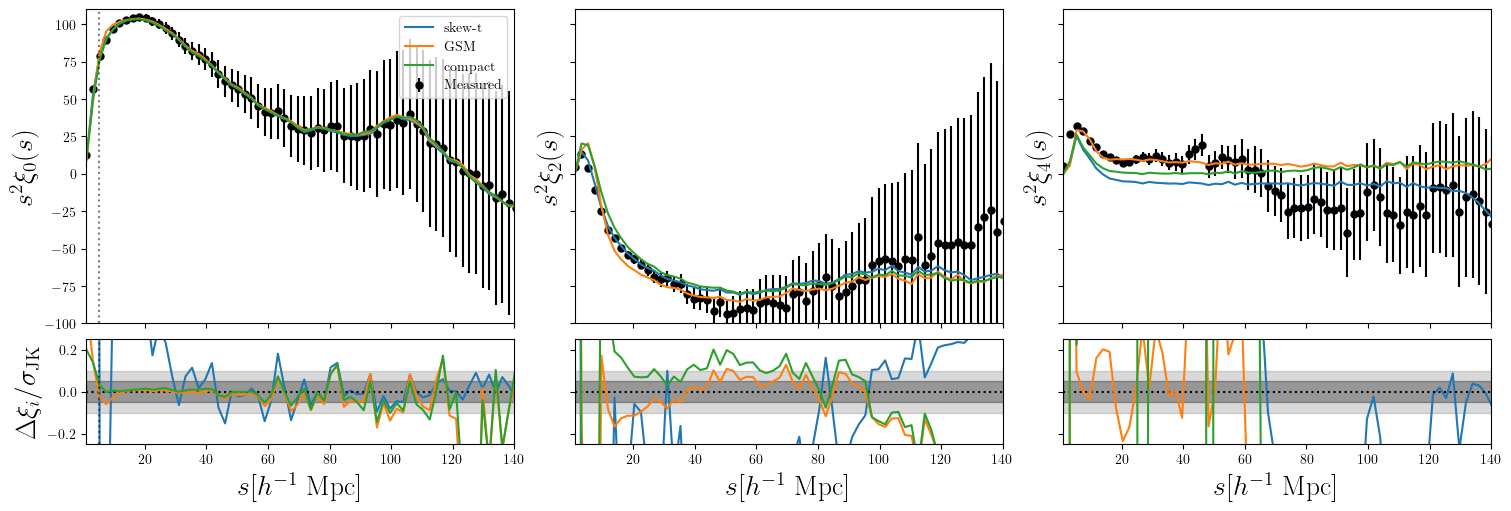

In [56]:
fig, axes = plot_multipoles_n_residuals(rbins_c, xi_ell, errs=xi_ell_std, preds=[skewt_monopole, skewt_quadrupole, skewt_hexadecapole], label='skew-t',)

compact_multipoles = [compact_monopole, compact_quadrupole, compact_hexadecapole]
gaussian_multipoles = [gaussian_monopole, gaussian_quadrupole, gaussian_hexadecapole]
multipoles = [monopole, quadrupole, hexadecapole]

for i, gm in enumerate(gaussian_multipoles):
    axes[0, i].plot(rbins_c, rbins_c**2*gm, label='GSM')

    axes[1, i].plot(rbins_c, (multipoles[i]-gm)/gm)

    axes[0, i].plot(rbins_c, rbins_c**2*compact_multipoles[i], label='compact')

    axes[1, i].plot(rbins_c, (multipoles[i]-compact_multipoles[i])/compact_multipoles[i])


axes[0, 0].axvline(5, c='k', ls=':', alpha=0.5)
axes[1, 0].axvline(5, c='k', ls=':', alpha=0.5)

axes[0, 0].set_ylim((-100, 110))
axes[0, 0].set_xlim((1, 140))
axes[0, 1].set_xlim((1, 140))
axes[0, 2].set_xlim((1, 140))

axes[0, 0].legend()

In [ ]:
# success!!!

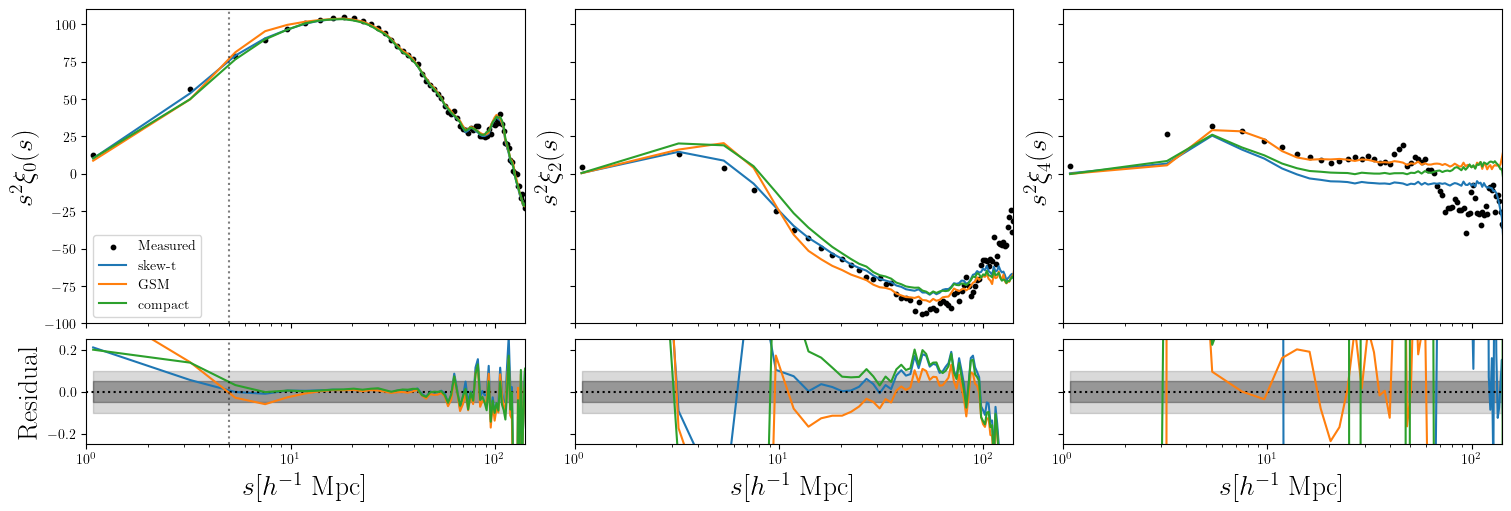

In [57]:
fig, axes = plot_multipoles_n_residuals(rbins_c, [monopole, quadrupole, hexadecapole], errs=None, preds=[skewt_monopole, skewt_quadrupole, skewt_hexadecapole], label='skew-t',)

compact_multipoles = [compact_monopole, compact_quadrupole, compact_hexadecapole]
gaussian_multipoles = [gaussian_monopole, gaussian_quadrupole, gaussian_hexadecapole]
multipoles = [monopole, quadrupole, hexadecapole]

for i, gm in enumerate(gaussian_multipoles):
    axes[0, i].plot(rbins_c, rbins_c**2*gm, label='GSM')

    axes[1, i].plot(rbins_c, (multipoles[i]-gm)/gm)

    axes[0, i].plot(rbins_c, rbins_c**2*compact_multipoles[i], label='compact')

    axes[1, i].plot(rbins_c, (multipoles[i]-compact_multipoles[i])/compact_multipoles[i])

    axes[0, i].set_xscale('log')
    axes[1, i].set_xscale('log')


axes[0, 0].axvline(5, c='k', ls=':', alpha=0.5)
axes[1, 0].axvline(5, c='k', ls=':', alpha=0.5)

axes[0, 0].set_ylim((-100, 110))
axes[0, 0].set_xlim((1, 140))
axes[0, 1].set_xlim((1, 140))
axes[0, 2].set_xlim((1, 140))

axes[0, 0].legend()